In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the clean artifact we generated in Notebook 1
df = pd.read_csv('../data/cleaned_water_data.csv')

print("✅ Clean Data Loaded! Shape:", df.shape)

✅ Clean Data Loaded! Shape: (422, 42)


In [5]:
# # All 20 Raw Water metrics (Our Inputs / X)
# features_x = [
#     'RW pH', 'RW Tur', 'RW Colour', 'RW TDS', 'RW Iron', 'RW  Hardness', 
#     'RW S Solids', 'RW Aluminium', 'RW Chloride', 'RW Manganese', 
#     'RW Conductivity ', 'RW Calcium', 'RW Calcium.1', 'RW Magnesium', 
#     'RW Magnesium.1', 'RW Alkalinity', 'RW Ammonia as N', 
#     'RW Total algal counts', 'RW Fecal coliform', 'RW Total coliform'
# ]

# # The matching 20 Treated Water metrics (Our Outputs / Y)
# targets_y = [
#     'TW pH', 'TW Tur', 'TW Colour', 'TW TDS', 'TW Iron', 'TW Hardness', 
#     'TW S Solids', 'TW Aluminium', 'TW Chloride', 'TW Manganese', 
#     'TW Conductivity', 'TW Calcium', 'TW Calcium.1', 'TW Magnesium', 
#     'TW Magnesium.1', 'TW Alkalinity', 'TW Ammonia as N', 
#     'TW Total algal counts', 'TW Fecal coliform', 'TW Total coliform'
# ]

# 1. Dynamically grab ALL columns that start with 'RW' (Our Inputs / X)
features_x = [col for col in df.columns if col.startswith('RW')]

# 2. Dynamically grab ALL columns that start with 'TW' (Our Outputs / Y)
targets_y = [col for col in df.columns if col.startswith('TW')]


# Create the isolated DataFrames
X = df[features_x]
Y = df[targets_y]

print(f"Inputs (X) shape: {X.shape} - (422 days, 20 features)")
print(f"Outputs (Y) shape: {Y.shape} - (422 days, 20 targets)")

Inputs (X) shape: (422, 20) - (422 days, 20 features)
Outputs (Y) shape: (422, 21) - (422 days, 20 targets)


In [6]:
# Split the data: 80% for training, 20% for testing
# random_state=42 ensures we get the exact same random split every time we run the code
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"📚 Training the AI on {X_train.shape[0]} historical days...")
print(f"🧪 Testing the AI on {X_test.shape[0]} unseen days...")

📚 Training the AI on 337 historical days...
🧪 Testing the AI on 85 unseen days...


In [8]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 1. Define a dictionary of models to test
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    # Wrap Gradient Boosting so it can predict all 20 columns simultaneously
    "Gradient Boosting": MultiOutputRegressor(GradientBoostingRegressor(random_state=42))
}


results = {}

# 2. Loop through each model, train it, and test it
for name, model in models.items():
    # Train the model on the 80% hidden data
    model.fit(X_train, Y_train)
    
    # Make predictions on the 20% test data
    predictions = model.predict(X_test)
    
    # Calculate average metrics across all 20 predicted columns
    # We use macro-averaging (uniform_average) to treat every chemical equally
    r2 = r2_score(Y_test, predictions, multioutput='uniform_average')
    rmse = np.sqrt(mean_squared_error(Y_test, predictions))
    
    results[name] = {'R2': r2, 'RMSE': rmse}
    
    print(f"✅ {name} trained.")

# 3. Print the final scoreboard
print("\n🏆 FINAL SCOREBOARD (Test Data) 🏆")
print(f"{'Algorithm':<22} | {'Avg R² Score':<12} | {'Avg RMSE'}")
print("-" * 50)

# Sort results by best R2 score (highest is better)
sorted_results = dict(sorted(results.items(), key=lambda item: item[1]['R2'], reverse=True))

for name, metrics in sorted_results.items():
    print(f"{name:<22} | {metrics['R2']:.4f}       | {metrics['RMSE']:.4f}")

✅ Linear Regression trained.
✅ Ridge Regression trained.


C:\Users\Vijayasimha\workspaces\water_quality_monitoring_and_forecasting\venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.5029134708364168e-16.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


✅ Random Forest trained.
✅ K-Nearest Neighbors trained.
✅ Gradient Boosting trained.

🏆 FINAL SCOREBOARD (Test Data) 🏆
Algorithm              | Avg R² Score | Avg RMSE
--------------------------------------------------
Gradient Boosting      | 0.8458       | 2.0359
Linear Regression      | 0.8044       | 2.4524
Ridge Regression       | 0.7521       | 2.4287
Random Forest          | 0.7380       | 3.0621
K-Nearest Neighbors    | 0.6479       | 4.2656


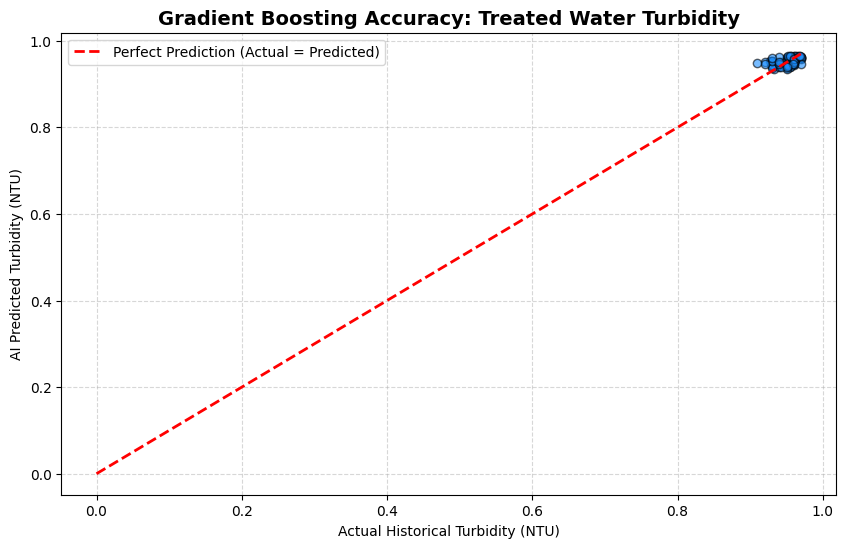

In [9]:
# 1. Isolate the winning model
best_model = models["Gradient Boosting"]

# 2. Get its exact predictions for the hidden test data
y_pred = best_model.predict(X_test)

# 3. y_pred is a massive 2D array. We need to find which column index belongs to 'TW Tur'
# targets_y is our list of 20 output columns. Let's find the index of Turbidity.
tur_index = targets_y.index('TW Tur')

# 4. Extract just the actual and predicted Turbidity values
actual_turbidity = Y_test.iloc[:, tur_index].values
predicted_turbidity = y_pred[:, tur_index]

# 5. Plot Actual vs. Predicted

plt.figure(figsize=(10, 6))
plt.scatter(actual_turbidity, predicted_turbidity, alpha=0.6, color='dodgerblue', edgecolor='k')

# Draw the "Perfect Prediction" diagonal line
max_val = max(max(actual_turbidity), max(predicted_turbidity))
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction (Actual = Predicted)')

plt.title('Gradient Boosting Accuracy: Treated Water Turbidity', fontsize=14, fontweight='bold')
plt.xlabel('Actual Historical Turbidity (NTU)')
plt.ylabel('AI Predicted Turbidity (NTU)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [10]:
# 1. Grab exactly ONE day of incoming Raw Water from our test set
# (We reshape it because scikit-learn expects a 2D array, even for one row)
single_day_rw = X_test.iloc[0].values.reshape(1, -1)

# 2. Ask the AI to predict the outgoing Treated Water
predicted_tw_array = best_model.predict(single_day_rw)[0]

# 3. Print the results in a beautiful, readable format
print("💧 AI DIGITAL TWIN PREDICTION 💧")
print("Based on today's Raw Water, the plant will output:\n")

# Zip the target names with the predicted numbers and format them cleanly
for chemical, prediction in zip(targets_y, predicted_tw_array):
    print(f"{chemical:<22}: {prediction:.3f}")

💧 AI DIGITAL TWIN PREDICTION 💧
Based on today's Raw Water, the plant will output:

TW pH                 : 7.555
TW Tur                : 0.960
TW FRC                : 0.677
TW Colour             : 2.071
TW TDS                : 124.851
TW Iron               : 0.253
TW Hardness           : 43.350
TW S Solids           : 0.809
TW Aluminium          : 0.029
TW Chloride           : 19.688
TW Manganese          : 0.031
TW Conductivity       : 187.493
TW Calcium            : 38.332
TW Calcium.1          : 15.333
TW Magnesium          : 7.795
TW Magnesium.1        : 1.974
TW Alkalinity         : 47.969
TW Ammonia as N       : 0.101
TW Total algal counts : 0.000
TW Fecal coliform     : 2.000
TW Total coliform     : 2.000


C:\Users\Vijayasimha\workspaces\water_quality_monitoring_and_forecasting\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
C:\Users\Vijayasimha\workspaces\water_quality_monitoring_and_forecasting\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
C:\Users\Vijayasimha\workspaces\water_quality_monitoring_and_forecasting\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(
C:\Users\Vijayasimha\workspaces\water_quality_monitoring_and_forecasting\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with fea

In [12]:
import joblib
import os

# 1. Define the path where we want to save the model file
model_filename = '../models/multi_output_regressor.pkl'

# 2. Save (serialize) the winning Gradient Boosting model
joblib.dump(best_model, model_filename)

print(f"✅ Success! The AI brain has been permanently saved to: {model_filename}")
print(f"File size: {os.path.getsize(model_filename) / 1024:.2f} KB")

✅ Success! The AI brain has been permanently saved to: ../models/multi_output_regressor.pkl
File size: 2481.82 KB
